In [1]:

import matplotlib.colors as mcolors
import matplotlib.path as mpath


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# import cmocean


In [2]:
ds_OAG = pd.read_csv("OAG2022.csv")

/tmp/ipykernel_734387/2051482667.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  ds_OAG = pd.read_csv("OAG2022.csv")


In [5]:
ds_OAG.head()

,Origin.Airport,Destination.Airport,Aircraft.Type,Seats,Number.of.Operations,distance(nm),fuel.per.flight(kg),fuel.per.flight.APU(kg),total.fuel(kg),time(s),...,nox.per.flight(g),PMnvol.per.flight(g),nox.per.flight.APU(g),PMnvol.per.flight.APU(g),cruise.fuel(kg),cruise.nox(g),cruise.nvpm(g),cruise.nvpm(num),notes,Unnamed: 21
0,AAA,FAC,AT7,64,1.0,84.463,456.849,53.655,456.849,2476.226,...,5409.706,2.540,273.642,2.540,246.786,3423.28,0.000,0.0,NaN,NaN
1,AAA,FAC,AT7,59,1.0,84.463,456.849,53.655,456.849,2476.226,...,5409.706,2.540,273.642,2.540,246.786,3423.28,0.000,0.0,NaN,NaN
2,AAA,FAC,AT7,60,2.0,84.463,456.849,53.655,913.697,2476.226,...,5409.706,2.540,273.642,2.540,246.786,3423.28,0.000,0.0,NaN,NaN
3,AAD,MGQ,F50,50,4.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.0,missing_depapt,NaN
4,AAE,ALG,73H,148,4.0,214.199,2551.107,91.613,10204.428,3317.234,...,47661.688,128.907,608.313,1.581,1876.633,38262.78,104.937,703163289493410432.0,NaN,NaN


In [4]:
ds_OAG.head()

# Make a pivot table
df_pivot = ds_OAG.pivot(index="Origin.Airport", columns="Destination.Airport", values="distance(nm)")
df_pivot = df_pivot.fillna(0)

# Create the meshgrid
lon, lat = np.meshgrid(df_pivot.columns, df_pivot.index)

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:

month,year = 12,2022
df_month = pd.read_parquet(
            f"{FLIGHT_DATA_PATH}{str(month).zfill(2)}_{str(year)}/2D_cell_inefficiency_1000pctmax_v3_new_{str(month).zfill(2)}_{str(year)}.parq"
)
df_month['samples_times_inefficiency'] =df_month["samples_in_cell"] * df_month["mean_cruise_inefficiency"]
gb = df_month.groupby(["lat_grid", "lon_grid"])
df = pd.DataFrame()
df["samples_in_cell"] = gb["samples_in_cell"].sum()
df["mean_cruise_inefficiency"] = (
        gb["samples_times_inefficiency"].sum() / df["samples_in_cell"]
    )

df = df[df["samples_in_cell"] > 5]

# round index to 2 decimal places
df.index = df.index.set_levels(
    [
        np.round(df.index.levels[0], 2),
        np.round(df.index.levels[1], 2),
    ]
)

In [ ]:
df.head()

samples_in_cell  mean_cruise_inefficiency    lat     lon
lat_grid lon_grid                                                          
-55.75   -127.00                 6                  2.360130 -55.75 -127.00
         -126.75                 6                  2.360130 -55.75 -126.75
         -126.50                 6                  2.360130 -55.75 -126.50
         -126.25                 7                  2.191808 -55.75 -126.25
         -126.00                 7                  2.191808 -55.75 -126.00

In [ ]:
df_month.head()

samples_in_cell  mean_cruise_inefficiency  \
lat_grid lon_grid                                              
-70.25   -144.00                 1                       0.0   
         -143.75                 1                       0.0   
         -143.50                 1                       0.0   
         -143.25                 1                       0.0   
         -143.00                 1                       0.0   

                   std_cruise_inefficiency  flights_above_10  \
lat_grid lon_grid                                              
-70.25   -144.00                       NaN                 0   
         -143.75                       NaN                 0   
         -143.50                       NaN                 0   
         -143.25                       NaN                 0   
         -143.00                       NaN                 0   

                   flights_above_20  percent_above_10  percent_above_20  \
lat_grid lon_grid                                                         
-70.25   -144.00                  0               0.0               0.0   
         -143.75                  0               0.0               0.0   
         -143.50                  0               0.0               0.0   
         -143.25                  0               0.0               0.0   
         -143.00                  0               0.0               0.0   

                   samples_times_inefficiency  
lat_grid lon_grid                              
-70.25   -144.00                          0.0  
         -143.75                          0.0  
         -143.50                          0.0  
         -143.25                          0.0  
         -143.00                          0.0

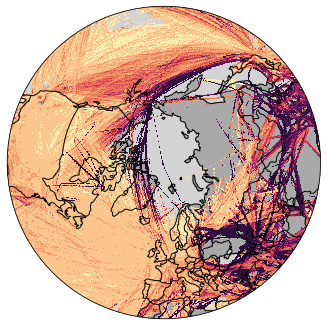

In [ ]:


# reindex so that all combinations of grid_latitudes and grid_longitudes are present and fill NaNs with 0
# df = df.reindex(
#     pd.MultiIndex.from_product(
#         [grid_latitudes, grid_longitudes], names=["lat", "lon"]
#     )
# ).fillna(0)

# coastline_width = 1
# coastline_color = "black"
# coastline_alpha = 1

# border_width = 1
# border_color = "black"
# border_alpha = 1
# border_linestyle = "solid"

# land_color = "grey"
# land_alpha = 0.5

# ocean_color = "lightgray"
# ocean_alpha = 0.5

df["lat"] = df.index.get_level_values(0)
df["lon"] = df.index.get_level_values(1)

df_pivot = df.pivot(index="lat", columns="lon", values="mean_cruise_inefficiency")
df_pivot = df_pivot.fillna(0)

# Create the meshgrid
lon, lat = np.meshgrid(df_pivot.columns, df_pivot.index)

# cmap = cm.get_cmap("coolwarm")
cmap = cmocean.cm.matter
cmap_name = "matter"

min_inef_threshold = 0
max_inef_threshold = 10
norm = mcolors.BoundaryNorm(
    np.linspace(min_inef_threshold, max_inef_threshold, 11), cmap.N, clip=True
)

# cmap = cmocean.cm.thermal.reversed()

projection = ccrs.NorthPolarStereo(
    central_longitude=0
)  # ccrs.NearsidePerspective(central_longitude=0, central_latitude=90, satellite_height=5000000)

fig = plt.figure(figsize=(7, 5.75))
ax = plt.axes(projection=projection)
ax.set_extent([-180, 180, 30, 90], ccrs.PlateCarree())
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=coastline_width,
    edgecolor=coastline_color,
    alpha=coastline_alpha,
)
ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor=land_color, alpha=land_alpha)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=border_width,
    edgecolor=border_color,
    alpha=border_alpha,
    linestyle=border_linestyle,
)

# ax.gridlines(
#     color="C7",
#     lw=1,
#     ls=":",
#     draw_labels=True,
#     rotate_labels=False,
#     ylocs=[60, 70, 80],
# )

c = ax.pcolormesh(
    lon,
    lat,
    df_pivot.values,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    alpha=1,
)



In [ ]:
lon.shape, lat.shape, df_pivot.values.shape

((583, 1441), (583, 1441), (583, 1441))

In [ ]:
lon

array([[-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75],
       [-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75],
       [-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75],
       ...,
       [-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75],
       [-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75],
       [-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,  180.75]])

In [ ]:
lat

array([[-55.75, -55.75, -55.75, ..., -55.75, -55.75, -55.75],
       [-55.5 , -55.5 , -55.5 , ..., -55.5 , -55.5 , -55.5 ],
       [-55.25, -55.25, -55.25, ..., -55.25, -55.25, -55.25],
       ...,
       [ 89.25,  89.25,  89.25, ...,  89.25,  89.25,  89.25],
       [ 89.5 ,  89.5 ,  89.5 , ...,  89.5 ,  89.5 ,  89.5 ],
       [ 89.75,  89.75,  89.75, ...,  89.75,  89.75,  89.75]])

In [ ]:
df_pivot.head()

lon,-180.00,-179.75,-179.50,-179.25,-179.00,-178.75,-178.50,-178.25,-178.00,-177.75,...,177.75,178.00,178.25,178.50,178.75,179.00,179.25,179.50,179.75,180.75
lat,,,,,,,,,,,,,,,,,,,,,
-55.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-55.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-55.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-54.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Average Excess Fuel Consumption')

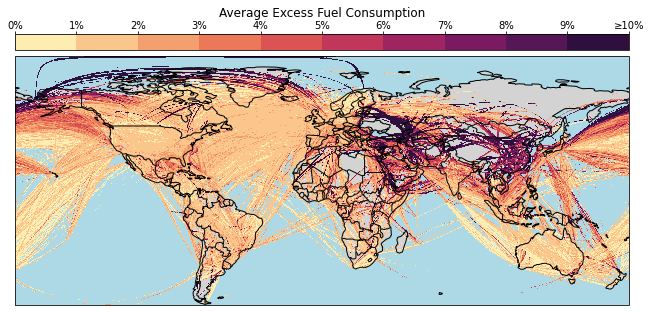

In [ ]:
cmap = cmocean.cm.matter
norm = mcolors.BoundaryNorm(
    np.linspace(0, 10, 11), cmap.N, clip=True
)





fig, ax = plt.subplots(
    figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

c = ax.pcolormesh(
    lon,
    lat,
    df_pivot.values,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
    alpha=1,
)

cbar = fig.colorbar(
    c, ax=ax, orientation="horizontal", location="top", pad=0.02, aspect=40
)

yticks = list(np.round(np.linspace(0, 10, 11), 3))

yticklabels = (
    [f"{min_inef_threshold}%"]
    + list(f"{str(int(ytick))}%" for ytick in yticks[1:-1])
    + [f"≥{max_inef_threshold}%"]
)
cbar.set_ticks(yticks)
cbar.set_ticklabels(yticklabels)
cbar.ax.tick_params(labelsize=10, pad=0)
cbar.ax.set_xlabel("Average Excess Fuel Consumption", fontsize=12)


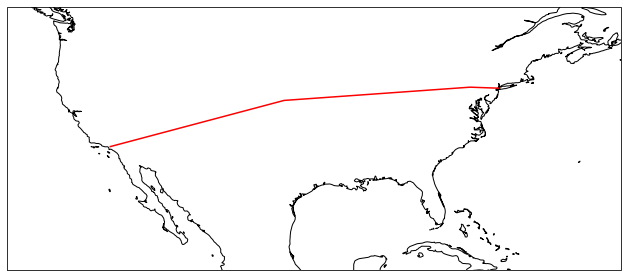

In [ ]:

fig, ax = plt.subplots(
    figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

la_lat, la_lon = 34.0522, -118.2437
ny_lat, ny_lon = 40.7128, -74.0060

ax.set_extent([-130, -60, 20, 50], ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1)

ax.plot([la_lon, ny_lon], [la_lat, ny_lat], color = 'red', transform = ccrs.Geodetic())